# Perceptrón: Segmentación de Colores en Imagen Real (Flor)

Entrenamos el perceptrón con pixeles de una imagen de una flor para segmentar las regiones de color: pétalos, centro, hojas y sombras.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from PIL import Image
import os

In [2]:
class Perceptron:
    def __init__(self, n_entradas, tasa_aprendizaje=0.01, epocas_maximas=100):
        self.pesos = np.random.uniform(-0.5, 0.5, n_entradas)
        self.umbral = np.random.uniform(-0.5, 0.5)
        self.tasa_aprendizaje = tasa_aprendizaje
        self.epocas_maximas = epocas_maximas
        self.historial_errores = []

    def funcion_activacion(self, suma):
        return 1 if suma >= 0 else 0

    def entrenar(self, X, Y):
        for epoca in range(self.epocas_maximas):
            errores_epoca = 0
            for i in range(len(X)):
                entradas = X[i]
                salida_deseada = Y[i]
                
                suma = np.dot(entradas, self.pesos) + self.umbral
                salida_obtenida = self.funcion_activacion(suma)
                
                error = salida_deseada - salida_obtenida
                if error != 0:
                    errores_epoca += 1
                    self.pesos += self.tasa_aprendizaje * error * entradas
                    self.umbral += self.tasa_aprendizaje * error
                    
            self.historial_errores.append(errores_epoca)
            if errores_epoca == 0:
                break

    def predecir(self, entradas):
        suma = np.dot(entradas, self.pesos) + self.umbral
        return self.funcion_activacion(suma)

    def activacion_cruda(self, entradas):
        return np.dot(entradas, self.pesos) + self.umbral

def predecir_multiclase(perceptrones, entradas):
    activaciones = [p.activacion_cruda(entradas) for p in perceptrones]
    return np.argmax(activaciones)

## 1. Cargar la imagen y extraer ROIs (Regiones de Interés)

In [3]:
# Cargar y redimensionar imagen para acelerar el procesamiento
ruta_imagen = 'imagen_flor.png'
if not os.path.exists(ruta_imagen):
    print(f"Error: No se encuentra {ruta_imagen}")

img_pil = Image.open(ruta_imagen).convert('RGB')
img_pil = img_pil.resize((400, 400)) # Redimensionar a 400x400
img_array = np.array(img_pil)

# Extraer regiones de color (y_inicio:y_fin, x_inicio:x_fin)
rois = {
    'Pétalos': img_array[150:250, 100:150],    # Blanco/Grisáceo
    'Centro': img_array[180:220, 180:220],     # Amarillo
    'Hojas': img_array[50:150, 50:150],        # Verde
    'Sombras': img_array[300:380, 300:380]     # Verde muy oscuro / Negro
}

colores_clases = {
    'Pétalos': '#F0F0F0',  # Blanco casi puro
    'Centro': '#FFD700',   # Dorado/Amarillo
    'Hojas': '#228B22',    # Verde bosque
    'Sombras': '#1A1A1A'   # Casi negro
}

# Preparar datos de entrenamiento
X_train = []
Y_clases = []

for idx, (nombre, roi) in enumerate(rois.items()):
    pixeles = roi.reshape(-1, 3) / 255.0  # Normalizar RGB a [0,1]
    X_train.extend(pixeles)
    Y_clases.extend([idx] * len(pixeles))

X_train = np.array(X_train)
Y_clases = np.array(Y_clases)

print(f"Dimensiones de la imagen: {img_array.shape}")
print(f"Muestras de entrenamiento totales: {len(X_train)}")
for nombre, roi in rois.items():
    print(f"  {nombre}: {roi.shape[0]*roi.shape[1]} muestras")

Dimensiones de la imagen: (400, 400, 3)
Muestras de entrenamiento totales: 23000
  Pétalos: 5000 muestras
  Centro: 1600 muestras
  Hojas: 10000 muestras
  Sombras: 6400 muestras


## 2. Entrenar Perceptrones (One-vs-All)

In [4]:
perceptrones = []
n_clases = len(rois)
nombres_clases = list(rois.keys())

for i in range(n_clases):
    print(f"Entrenando perceptrón para '{nombres_clases[i]}'...")
    Y_binario = np.where(Y_clases == i, 1, 0)
    
    p = Perceptron(n_entradas=3, tasa_aprendizaje=0.01, epocas_maximas=50)
    p.entrenar(X_train, Y_binario)
    perceptrones.append(p)

# Calcular precisión en entrenamiento
aciertos = 0
for i in range(len(X_train)):
    pred = predecir_multiclase(perceptrones, X_train[i])
    if pred == Y_clases[i]:
        aciertos += 1

print(f"Precisión en entrenamiento: {(aciertos/len(X_train))*100:.1f}%")

Entrenando perceptrón para 'Pétalos'...


Entrenando perceptrón para 'Centro'...


Entrenando perceptrón para 'Hojas'...


Entrenando perceptrón para 'Sombras'...


Precisión en entrenamiento: 35.4%


## 3. Segmentar toda la imagen

In [5]:
img_normalizada = img_array / 255.0
img_plana = img_normalizada.reshape(-1, 3)
predicciones = np.zeros(len(img_plana))

print("Segmentando imagen pixel por pixel...")
for i in range(len(img_plana)):
    predicciones[i] = predecir_multiclase(perceptrones, img_plana[i])

mapa_segmentado = predicciones.reshape(img_array.shape[:2])
print("¡Segmentación completada!")

Segmentando imagen pixel por pixel...


¡Segmentación completada!


## 4. Visualizar Resultados

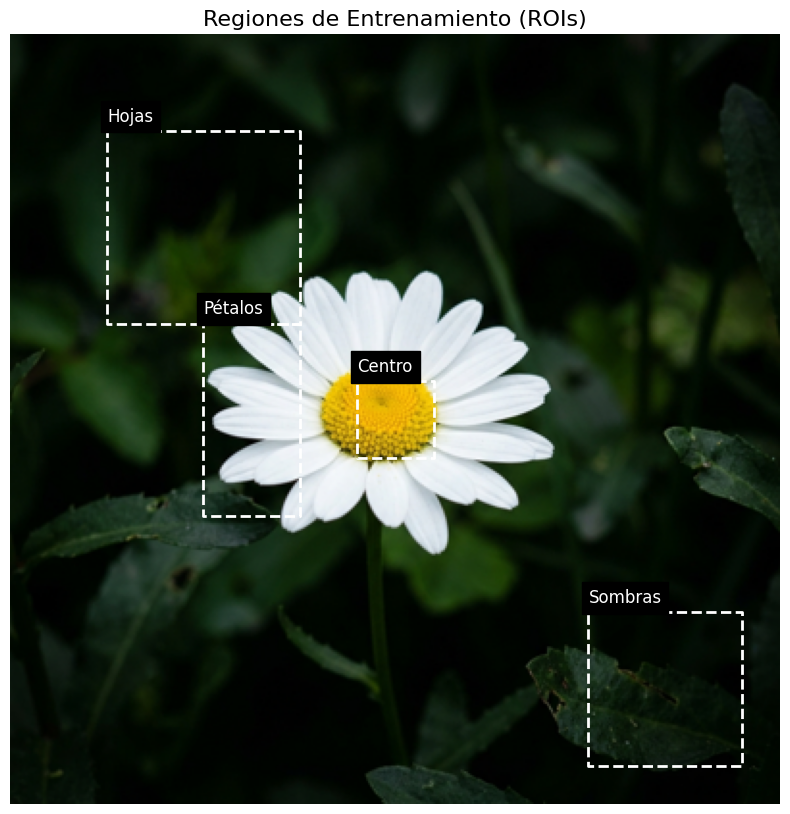

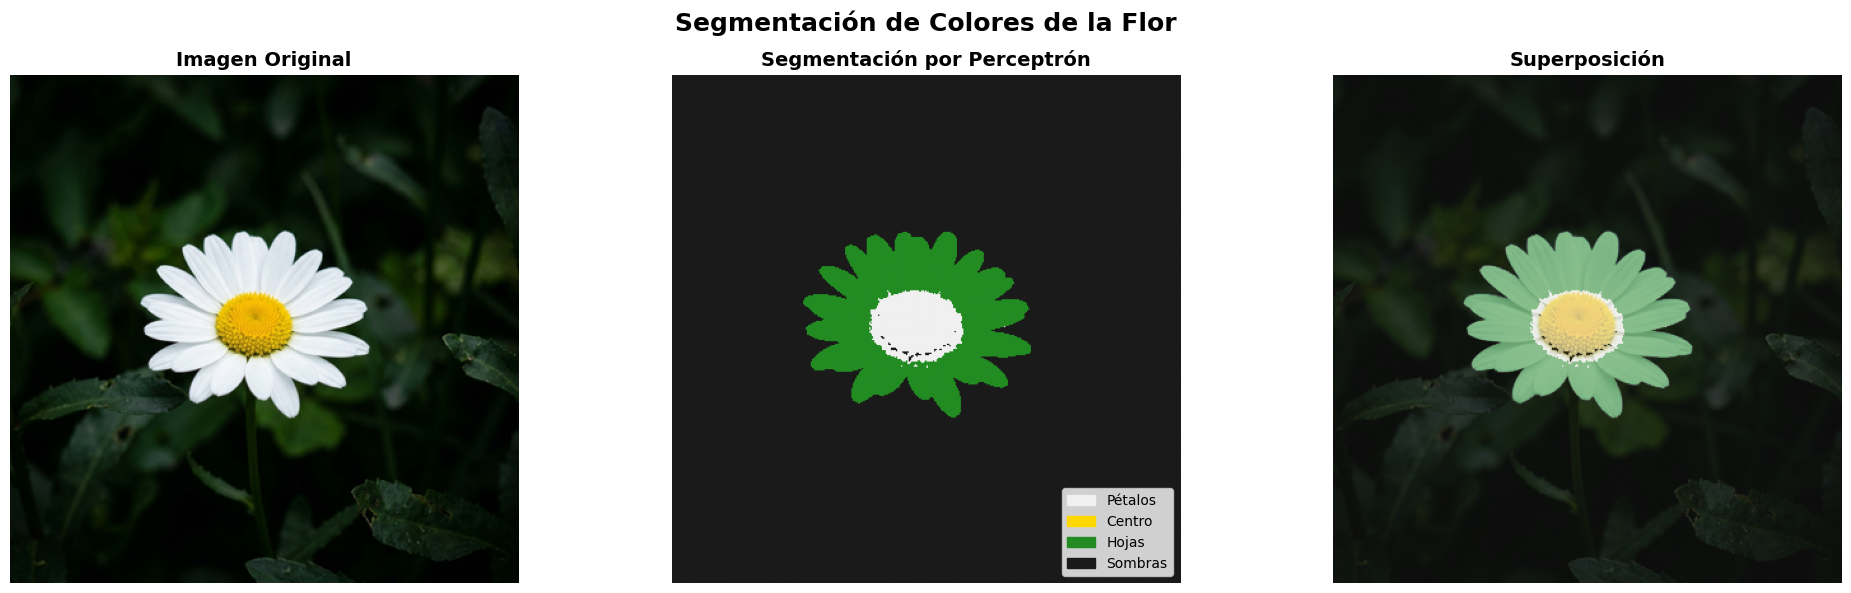

In [6]:
# 1. Mostrar Imagen Original y ROIs
plt.figure(figsize=(10, 10))
plt.imshow(img_array)
for nombre, roi_coords in zip(nombres_clases, [
    (150, 250, 100, 150), # y1,y2, x1,x2
    (180, 220, 180, 220),
    (50, 150, 50, 150),
    (300, 380, 300, 380)
]):
    y1, y2, x1, x2 = roi_coords
    plt.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], 'w--', lw=2)
    plt.text(x1, y1-5, nombre, color='white', backgroundcolor='black', fontsize=12)
plt.title("Regiones de Entrenamiento (ROIs)", fontsize=16)
plt.axis('off')
plt.show()

# 2. Mostrar Segmentación
cmap_custom = ListedColormap([colores_clases[c] for c in nombres_clases])

fig, ax = plt.subplots(1, 3, figsize=(20, 6))

ax[0].imshow(img_array)
ax[0].set_title('Imagen Original', fontsize=14, fontweight='bold')
ax[0].axis('off')

im_seg = ax[1].imshow(mapa_segmentado, cmap=cmap_custom)
ax[1].set_title('Segmentación por Perceptrón', fontsize=14, fontweight='bold')
ax[1].axis('off')

ax[2].imshow(img_array)
ax[2].imshow(mapa_segmentado, cmap=cmap_custom, alpha=0.5)
ax[2].set_title('Superposición', fontsize=14, fontweight='bold')
ax[2].axis('off')

import matplotlib.patches as mpatches
parches = [mpatches.Patch(color=colores_clases[c], label=c) for c in nombres_clases]
ax[1].legend(handles=parches, loc='lower right')

plt.suptitle("Segmentación de Colores de la Flor", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Distribución de colores RGB por clase

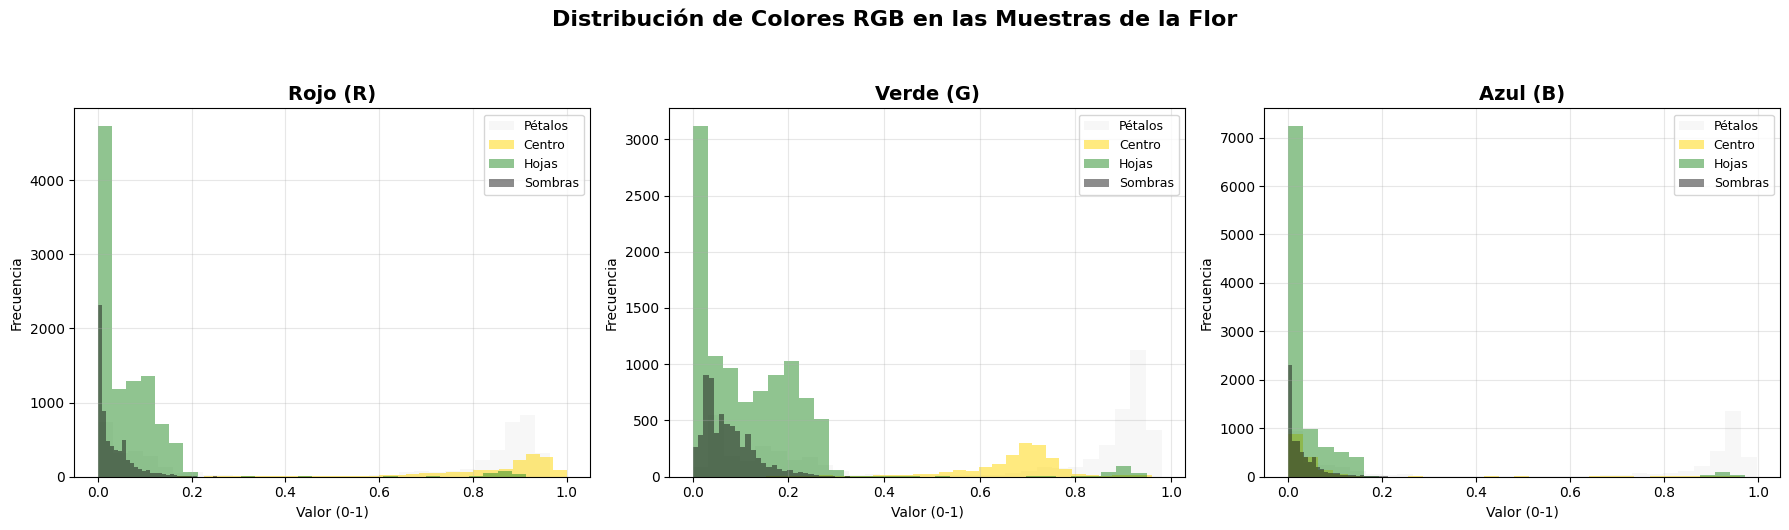


PESOS FINALES DE CADA PERCEPTRÓN
Pétalos     : R=-0.0719, G=-0.0824, B=+0.0914 | Umbral=-0.0078
Centro      : R=+0.2480, G=-0.0364, B=-0.1884 | Umbral=-0.0432
Hojas       : R=+0.2297, G=-0.3388, B=+0.0981 | Umbral=-0.0081
Sombras     : R=-0.0220, G=+0.0472, B=-0.1081 | Umbral=+0.0202


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
canales = ['Rojo (R)', 'Verde (G)', 'Azul (B)']
colores_hist = [colores_clases[c] for c in nombres_clases]

for i, canal in enumerate(canales):
    for c_idx, clase in enumerate(nombres_clases):
        datos_canal = X_train[Y_clases == c_idx][:, i]
        axes[i].hist(datos_canal, bins=30, alpha=0.5, label=clase, color=colores_hist[c_idx])
    
    axes[i].set_title(canal, fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Valor (0-1)")
    axes[i].set_ylabel("Frecuencia")
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)

plt.suptitle("Distribución de Colores RGB en las Muestras de la Flor", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Imprimir pesos finales
print("\n" + "="*50)
print("PESOS FINALES DE CADA PERCEPTRÓN")
print("="*50)
for i, p in enumerate(perceptrones):
    print(f"{nombres_clases[i]:<12}: R={p.pesos[0]:+.4f}, G={p.pesos[1]:+.4f}, B={p.pesos[2]:+.4f} | Umbral={p.umbral:+.4f}")